# Replicarea DirectNet — Partea 2
## Blind-block, antrenare self-supervised și harta de anomalii

Implementăm ideea centrală din articol:

- patch `Wout × Wout` pentru fiecare pixel;
- bloc central `Win × Win` înlocuit cu pixeli din exterior;
- predicția spectrului pixelului central;
- loss **L1** la antrenare;
- scor de anomalie **L2** la evaluare.

Aceasta este o reimplementare după descrierea din articol, nu codul oficial al autorilor.

Rezultatele baseline obținute deja:

- HSI: `150 × 150 × 102`;
- 68 pixeli anomalie (`0.3022%`);
- AUC GRX: `0.9677`;
- timp GRX: aproximativ `0.258 s`.

## 1. Configurarea mediului

În Google Colab selectează `Runtime → Change runtime type → T4 GPU`.

In [ ]:
import copy
import random
import sys
import time
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    precision_score, recall_score, f1_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, RandomSampler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## 2. Hiperparametrii inițiali

Pentru Pavia, articolul folosește `Wout=19`, `Win=3`, batch size 100 și learning rate `1e-4`.
Prima rulare folosește mai puține epoci și early stopping, ca să validăm implementarea.

In [ ]:
WOUT = 19
WIN = 3
BATCH_SIZE = 100
LEARNING_RATE = 1e-4

QUICK_MODE = False
if QUICK_MODE:
    MAX_EPOCHS = 50
    TRAIN_SAMPLES_PER_EPOCH = 6000
    VALIDATION_SAMPLES = 2000
    PATIENCE = 8
else:
    MAX_EPOCHS = 150
    TRAIN_SAMPLES_PER_EPOCH = 20000
    VALIDATION_SAMPLES = 2500
    PATIENCE = 15

INFERENCE_BATCH_SIZE = 256
NUM_WORKERS = 0

assert WOUT % 2 == 1
assert WIN % 2 == 1 and 1 < WIN < WOUT
assert (WOUT - 7) % 4 == 0
N_RES_BLOCKS = (WOUT - 7) // 4

print("WOUT:", WOUT)
print("WIN:", WIN)
print("Blocuri ResNet:", N_RES_BLOCKS)
print("Max epochs:", MAX_EPOCHS)

WOUT: 19
WIN: 3
Blocuri ResNet: 3
Max epochs: 50


## 3. Descărcarea și încărcarea setului Pavia

In [ ]:
DATA_DIR = Path("/content/directnet_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = DATA_DIR / "pavia.mat"

URLS = [
    "https://raw.githubusercontent.com/jeline0110/GT-HAD/main/data/pavia.mat",
    "https://github.com/jeline0110/GT-HAD/raw/main/data/pavia.mat",
]

if not DATA_PATH.exists():
    last_error = None
    for url in URLS:
        try:
            print("Descarc:", url)
            urllib.request.urlretrieve(url, DATA_PATH)
            break
        except Exception as exc:
            last_error = exc
            print("Eroare:", exc)
    else:
        raise RuntimeError(
            "Descărcarea a eșuat. Încarcă manual pavia.mat în "
            "/content/directnet_data/pavia.mat. " + str(last_error)
        )

print("Fișier:", DATA_PATH)
print("Dimensiune MB:", DATA_PATH.stat().st_size / 1024**2)

Descarc: https://raw.githubusercontent.com/jeline0110/GT-HAD/main/data/pavia.mat
Fișier: /content/directnet_data/pavia.mat
Dimensiune MB: 8.220309257507324


In [ ]:
def orient_cube_to_gt(cube, gt_shape):
    candidates = [
        cube,
        np.transpose(cube, (1, 2, 0)),
        np.transpose(cube, (0, 2, 1)),
        np.transpose(cube, (2, 0, 1)),
        np.transpose(cube, (1, 0, 2)),
        np.transpose(cube, (2, 1, 0)),
    ]
    for candidate in candidates:
        if candidate.shape[:2] == gt_shape:
            return candidate
    raise ValueError("Nu pot orienta cubul.")

mat = loadmat(DATA_PATH)
arrays = {
    k: v for k, v in mat.items()
    if not k.startswith("__") and isinstance(v, np.ndarray)
}

cubes = {k: v for k, v in arrays.items() if v.ndim == 3}
gts = {k: np.squeeze(v) for k, v in arrays.items() if np.squeeze(v).ndim == 2}

cube_key, cube_raw = max(cubes.items(), key=lambda item: item[1].size)
matched = None
for gt_key, gt_raw in gts.items():
    try:
        matched = (cube_key, orient_cube_to_gt(cube_raw, gt_raw.shape), gt_key, gt_raw)
        break
    except ValueError:
        pass

if matched is None:
    raise RuntimeError("Nu s-au putut asocia HSI și ground truth.")

cube_key, hsi, gt_key, gt = matched
hsi = np.nan_to_num(np.asarray(hsi, dtype=np.float32))
gt = np.asarray(gt)
gt_binary = gt.astype(np.uint8) if set(np.unique(gt)).issubset({0, 1}) else (gt > 0).astype(np.uint8)

H, W, B0 = hsi.shape
valid_bands = hsi.reshape(-1, B0).std(axis=0) > 1e-8
hsi = hsi[:, :, valid_bands]
H, W, B = hsi.shape

pixels = hsi.reshape(-1, B)
mean = pixels.mean(axis=0, keepdims=True)
std = np.maximum(pixels.std(axis=0, keepdims=True), 1e-8)
pixels_z = (pixels - mean) / std
hsi_z = pixels_z.reshape(H, W, B).astype(np.float32)

print("HSI:", hsi_z.shape)
print("GT:", gt_binary.shape)
print("Anomalii:", int(gt_binary.sum()))
print("Procent anomalie:", 100 * gt_binary.mean(), "%")

HSI: (150, 150, 102)
GT: (150, 150)
Anomalii: 68
Procent anomalie: 0.3022222222222222 %


## 4. Pseudocolor PCA

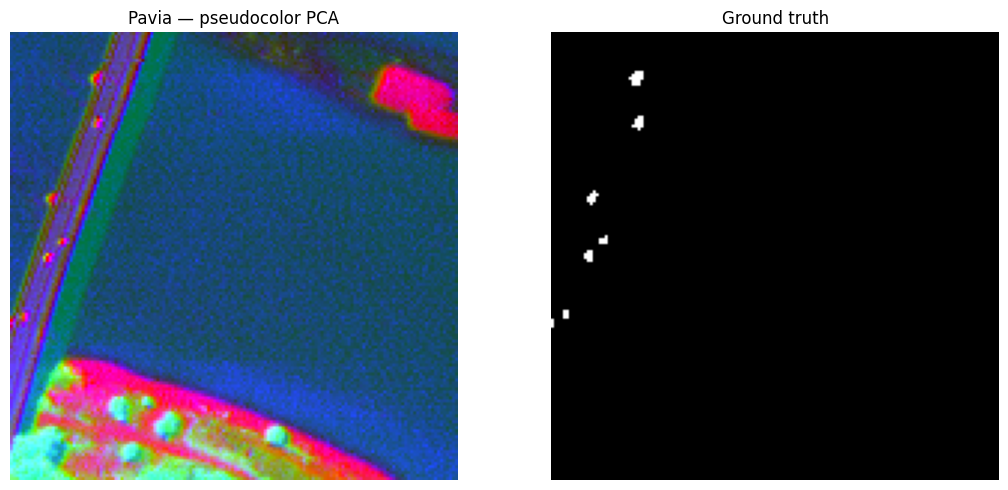

In [ ]:
def percentile_stretch(image, low=2, high=98):
    out = np.zeros_like(image, dtype=np.float32)
    for c in range(image.shape[-1]):
        lo, hi = np.percentile(image[..., c], [low, high])
        if hi > lo:
            out[..., c] = np.clip((image[..., c] - lo) / (hi - lo), 0, 1)
    return out

pca = PCA(n_components=3, random_state=SEED)
pca_rgb = percentile_stretch(pca.fit_transform(pixels_z).reshape(H, W, 3))

plt.figure(figsize=(11, 5))
plt.subplot(1, 2, 1)
plt.imshow(pca_rgb)
plt.title("Pavia — pseudocolor PCA")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(gt_binary, cmap="gray")
plt.title("Ground truth")
plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Patch-uri și blind-block

Pentru fiecare pixel extragem un patch `Wout × Wout × B`. Blocul central `Win × Win` este înlocuit cu pixeli selectați din exterior. Ținta rămâne spectrul original al pixelului central.

In [ ]:
class BlindBlockPatchDataset(Dataset):
    def __init__(self, hsi_hwc, wout, win, deterministic=False, seed=42):
        self.hsi = torch.from_numpy(hsi_hwc).float()
        self.h, self.w, self.b = hsi_hwc.shape
        self.wout = int(wout)
        self.win = int(win)
        self.pad = self.wout // 2
        self.center = self.wout // 2
        self.deterministic = deterministic
        self.seed = int(seed)

        chw = self.hsi.permute(2, 0, 1).unsqueeze(0)
        self.padded = F.pad(chw, (self.pad, self.pad, self.pad, self.pad), mode="reflect").squeeze(0)

        half = self.win // 2
        inner, outer = [], []
        for r in range(self.wout):
            for c in range(self.wout):
                inside = abs(r - self.center) <= half and abs(c - self.center) <= half
                (inner if inside else outer).append((r, c))

        self.inner_coords = torch.tensor(inner, dtype=torch.long)
        self.outer_coords = torch.tensor(outer, dtype=torch.long)

    def __len__(self):
        return self.h * self.w

    def __getitem__(self, index):
        row, col = divmod(index, self.w)
        patch = self.padded[:, row:row+self.wout, col:col+self.wout].clone()
        target = self.hsi[row, col].clone()

        generator = None
        if self.deterministic:
            generator = torch.Generator().manual_seed(self.seed + int(index))

        selected = torch.randint(
            0, len(self.outer_coords), (len(self.inner_coords),), generator=generator
        )
        src = self.outer_coords[selected]
        dst_r, dst_c = self.inner_coords[:, 0], self.inner_coords[:, 1]
        src_r, src_c = src[:, 0], src[:, 1]
        patch[:, dst_r, dst_c] = patch[:, src_r, src_c]
        return patch, target, int(index)

## 6. Verificarea vizuală a blind-block-ului

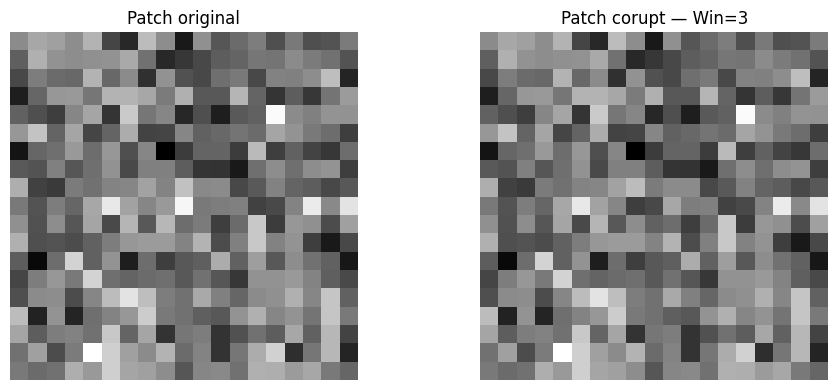

In [ ]:
preview_ds = BlindBlockPatchDataset(hsi_z, WOUT, WIN, deterministic=True, seed=SEED)
idx = (H // 2) * W + (W // 2)
corrupted, _, _ = preview_ds[idx]
row, col = divmod(idx, W)
pad = WOUT // 2
chw = torch.from_numpy(hsi_z).permute(2, 0, 1).unsqueeze(0)
padded = F.pad(chw, (pad, pad, pad, pad), mode="reflect").squeeze(0)
original = padded[:, row:row+WOUT, col:col+WOUT]
band = B // 2

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(original[band], cmap="gray")
plt.title("Patch original")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(corrupted[band], cmap="gray")
plt.title(f"Patch corupt — Win={WIN}")
plt.axis("off")
plt.tight_layout()
plt.show()

## 7. Arhitectura DirectNet

Numărul de blocuri reziduale este:

\[
N_r=\frac{W_{out}-7}{4}
\]

Pentru `Wout=19`, rezultă `Nr=3`.

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = self.bn2(self.conv2(x))
        return x + residual


class DirectNet(nn.Module):
    def __init__(self, bands, wout, hidden=64):
        super().__init__()
        self.center = wout // 2
        self.n_blocks = (wout - 7) // 4
        self.conv_in = nn.Conv2d(bands, hidden, 3, padding=1)
        self.blocks = nn.Sequential(*[ResidualBlock(hidden) for _ in range(self.n_blocks)])
        self.conv_mid = nn.Conv2d(hidden, hidden, 3, padding=1)
        self.bn_mid = nn.BatchNorm2d(hidden)
        self.conv_out = nn.Conv2d(hidden, bands, 3, padding=1)

    def forward(self, x):
        low = F.relu(self.conv_in(x), inplace=True)
        high = self.blocks(low)
        high = self.bn_mid(self.conv_mid(high))
        reconstructed = self.conv_out(low + high)
        return reconstructed[:, :, self.center, self.center]

model = DirectNet(B, WOUT, hidden=64).to(DEVICE)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print("Parametri antrenabili:", f"{params:,}")

DirectNet(
  (conv_in): Conv2d(102, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (blocks): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d

## 8. Train/validation self-supervised

Ground truth-ul nu este folosit la antrenare. El este folosit numai ulterior pentru evaluarea AUC și analiza FP/FN.

In [ ]:
indices = np.arange(H * W)
rng = np.random.default_rng(SEED)
rng.shuffle(indices)
n_val = min(VALIDATION_SAMPLES, max(1, int(0.1 * len(indices))))
val_idx = indices[:n_val]
train_idx = indices[n_val:]

train_base = BlindBlockPatchDataset(hsi_z, WOUT, WIN, deterministic=False, seed=SEED)
val_base = BlindBlockPatchDataset(hsi_z, WOUT, WIN, deterministic=True, seed=SEED + 10000)
train_subset = Subset(train_base, train_idx.tolist())
val_subset = Subset(val_base, val_idx.tolist())

train_sampler = RandomSampler(train_subset, replacement=True, num_samples=TRAIN_SAMPLES_PER_EPOCH)
train_loader = DataLoader(
    train_subset, batch_size=BATCH_SIZE, sampler=train_sampler,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda")
)
val_loader = DataLoader(
    val_subset, batch_size=INFERENCE_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda")
)

print("Train disponibil:", len(train_subset))
print("Validation:", len(val_subset))
print("Batch-uri/epocă:", len(train_loader))

Train disponibil: 20500
Validation: 2000
Batch-uri/epocă: 60


## 9. Antrenarea

Loss-ul este L1 între spectrul reconstruit și spectrul original al pixelului central.

In [ ]:
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6
)

history = {"train": [], "val": [], "lr": []}
best_state = None
best_val = float("inf")
no_improve = 0
start = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    train_sum = 0.0
    train_n = 0
    for patches, targets, _ in train_loader:
        patches = patches.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        pred = model(patches)
        loss = criterion(pred, targets)
        loss.backward()
        optimizer.step()
        train_sum += loss.item() * len(patches)
        train_n += len(patches)
    train_loss = train_sum / train_n

    model.eval()
    val_sum = 0.0
    val_n = 0
    with torch.no_grad():
        for patches, targets, _ in val_loader:
            patches = patches.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            loss = criterion(model(patches), targets)
            val_sum += loss.item() * len(patches)
            val_n += len(patches)
    val_loss = val_sum / val_n
    scheduler.step(val_loss)
    lr = optimizer.param_groups[0]["lr"]

    history["train"].append(train_loss)
    history["val"].append(val_loss)
    history["lr"].append(lr)

    if val_loss < best_val - 1e-5:
        best_val = val_loss
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1

    print(
        f"Epoch {epoch:03d}/{MAX_EPOCHS} | train={train_loss:.6f} | "
        f"val={val_loss:.6f} | lr={lr:.2e} | patience={no_improve}/{PATIENCE}"
    )
    if no_improve >= PATIENCE:
        print("Early stopping.")
        break

training_time = time.perf_counter() - start
model.load_state_dict(best_state)
print(f"Timp antrenare: {training_time/60:.2f} minute")
print("Best validation loss:", best_val)

Epoch 001/50 | train=0.309048 | val=0.191033 | lr=1.00e-04 | patience=0/8
Epoch 002/50 | train=0.175183 | val=0.164784 | lr=1.00e-04 | patience=0/8
Epoch 003/50 | train=0.156952 | val=0.145689 | lr=1.00e-04 | patience=0/8
Epoch 004/50 | train=0.142560 | val=0.146600 | lr=1.00e-04 | patience=1/8
Epoch 005/50 | train=0.139321 | val=0.134242 | lr=1.00e-04 | patience=0/8
Epoch 006/50 | train=0.132486 | val=0.131096 | lr=1.00e-04 | patience=0/8
Epoch 007/50 | train=0.130923 | val=0.138449 | lr=1.00e-04 | patience=1/8
Epoch 008/50 | train=0.126211 | val=0.131055 | lr=1.00e-04 | patience=0/8
Epoch 009/50 | train=0.119752 | val=0.129801 | lr=1.00e-04 | patience=0/8
Epoch 010/50 | train=0.115623 | val=0.126047 | lr=1.00e-04 | patience=0/8
Epoch 011/50 | train=0.119499 | val=0.127456 | lr=1.00e-04 | patience=1/8
Epoch 012/50 | train=0.111123 | val=0.129350 | lr=1.00e-04 | patience=2/8
Epoch 013/50 | train=0.110139 | val=0.108121 | lr=1.00e-04 | patience=0/8
Epoch 014/50 | train=0.105130 | val=0.

## 10. Curbele de învățare

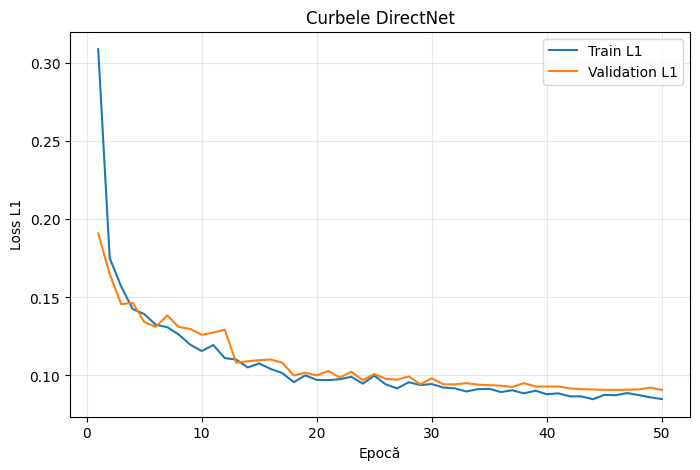

In [ ]:
epochs = np.arange(1, len(history["train"]) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train"], label="Train L1")
plt.plot(epochs, history["val"], label="Validation L1")
plt.xlabel("Epocă")
plt.ylabel("Loss L1")
plt.title("Curbele DirectNet")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 11. Reconstrucția tuturor pixelilor și harta de anomalii

Timp inferență: 8.087 s


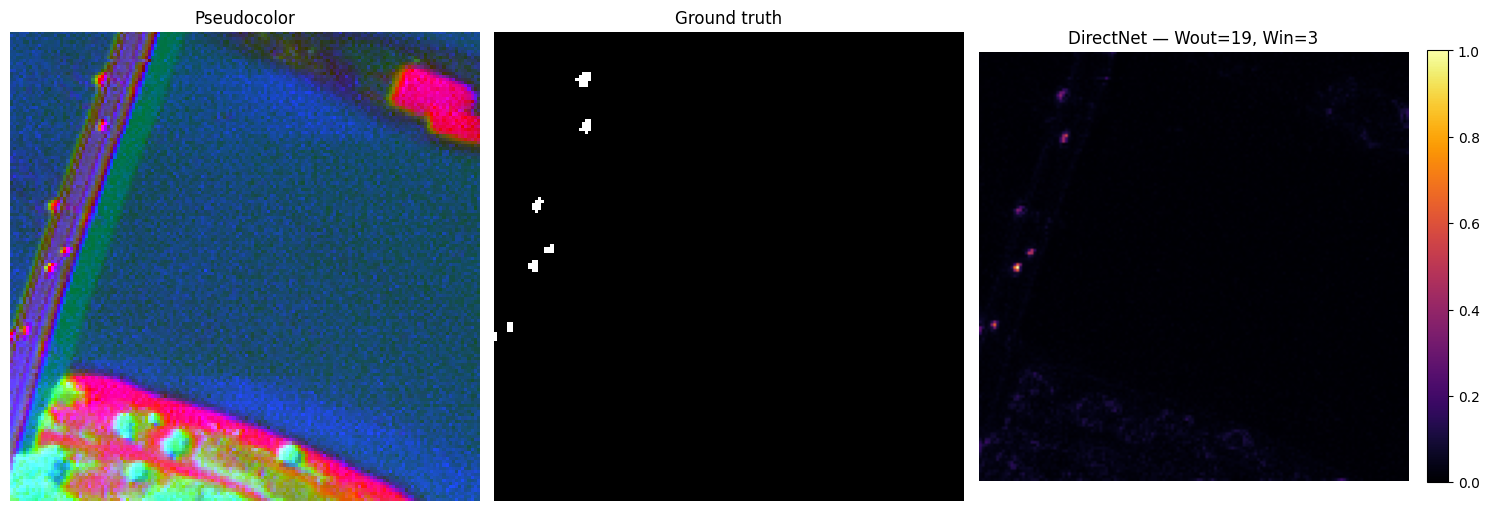

In [ ]:
eval_ds = BlindBlockPatchDataset(hsi_z, WOUT, WIN, deterministic=True, seed=SEED + 20000)
eval_loader = DataLoader(
    eval_ds, batch_size=INFERENCE_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda")
)

reconstructed = np.zeros((H * W, B), dtype=np.float32)
model.eval()
start = time.perf_counter()
with torch.no_grad():
    for patches, _, ids in eval_loader:
        pred = model(patches.to(DEVICE, non_blocking=True)).cpu().numpy()
        reconstructed[ids.numpy()] = pred
inference_time = time.perf_counter() - start

scores = np.linalg.norm(hsi_z.reshape(-1, B) - reconstructed, axis=1)
directnet_map = scores.reshape(H, W)
display_map = (directnet_map - directnet_map.min()) / (directnet_map.max() - directnet_map.min() + 1e-12)

print(f"Timp inferență: {inference_time:.3f} s")
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(pca_rgb)
plt.title("Pseudocolor")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(gt_binary, cmap="gray")
plt.title("Ground truth")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(display_map, cmap="inferno")
plt.title(f"DirectNet — Wout={WOUT}, Win={WIN}")
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis("off")
plt.tight_layout()
plt.show()

## 12. Comparația ROC/AUC cu GRX

AUC GRX       = 0.967705
AUC DirectNet = 0.984985
Diferență     = +0.017280


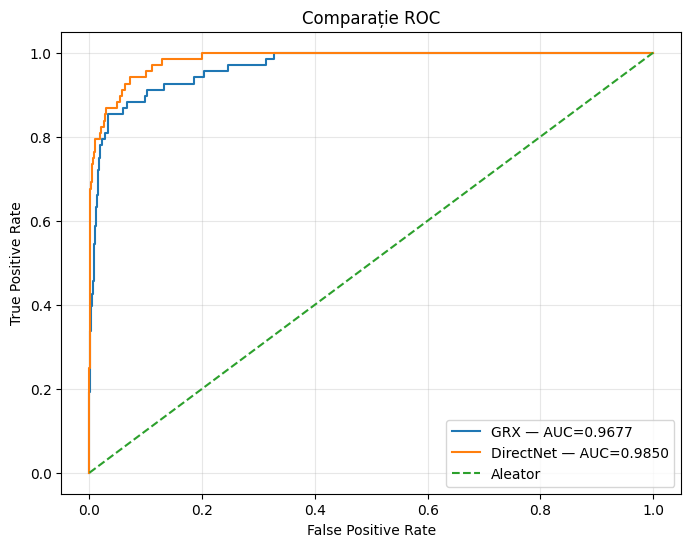

In [ ]:
def global_rx_scores(x, regularization=1e-3):
    centered = x - x.mean(axis=0, keepdims=True)
    cov = np.atleast_2d(np.cov(centered, rowvar=False))
    scale = np.trace(cov) / cov.shape[0]
    inv = np.linalg.pinv(cov + regularization * scale * np.eye(cov.shape[0]))
    return np.einsum("ij,jk,ik->i", centered, inv, centered, optimize=True)

y_true = gt_binary.ravel()
grx_scores = global_rx_scores(pixels_z)
auc_grx = roc_auc_score(y_true, grx_scores)
auc_directnet = roc_auc_score(y_true, scores)
fpr_g, tpr_g, _ = roc_curve(y_true, grx_scores)
fpr_d, tpr_d, thr_d = roc_curve(y_true, scores)

print(f"AUC GRX       = {auc_grx:.6f}")
print(f"AUC DirectNet = {auc_directnet:.6f}")
print(f"Diferență     = {auc_directnet - auc_grx:+.6f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr_g, tpr_g, label=f"GRX — AUC={auc_grx:.4f}")
plt.plot(fpr_d, tpr_d, label=f"DirectNet — AUC={auc_directnet:.4f}")
plt.plot([0, 1], [0, 1], "--", label="Aleator")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparație ROC")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 13. Prag, Precision, Recall, F1 și harta FP/FN

Pragul Youden este folosit doar pentru analiza experimentală. AUC nu necesită prag.

Prag Youden: 2.596256
TP=64, TN=20834, FP=1598, FN=4
Precision=0.038508
Recall=0.941176
F1=0.073988


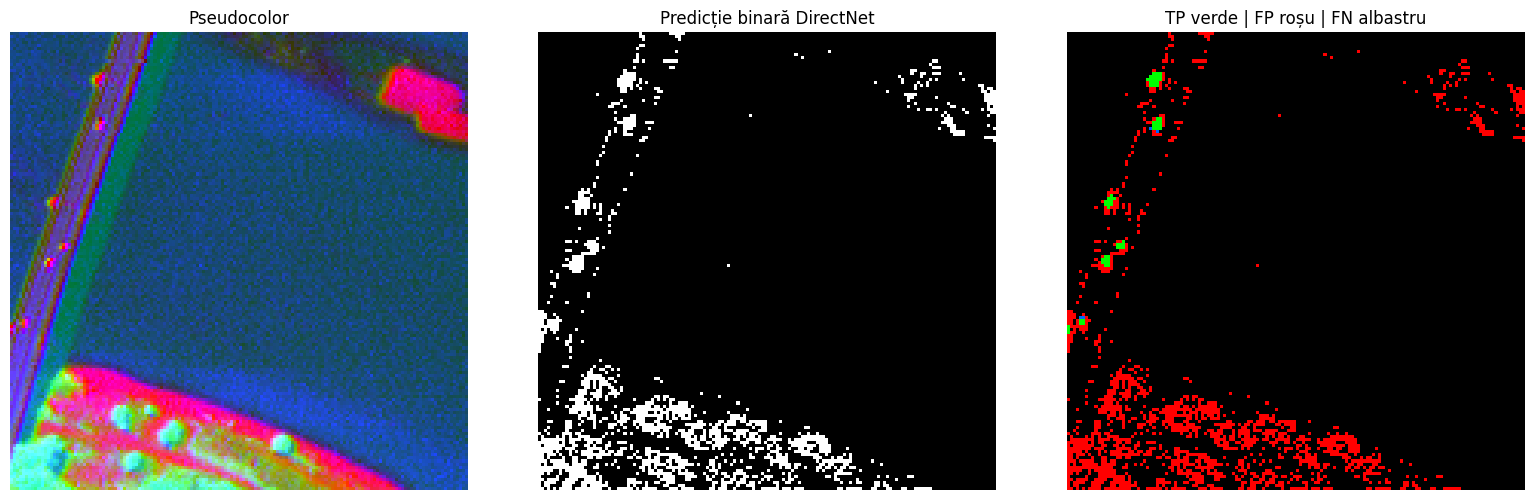

In [ ]:
best_idx = np.argmax(tpr_d - fpr_d)
threshold = thr_d[best_idx]
pred = (scores >= threshold).astype(np.uint8)
tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
precision = precision_score(y_true, pred, zero_division=0)
recall = recall_score(y_true, pred, zero_division=0)
f1 = f1_score(y_true, pred, zero_division=0)

print(f"Prag Youden: {threshold:.6f}")
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"Precision={precision:.6f}")
print(f"Recall={recall:.6f}")
print(f"F1={f1:.6f}")

pred_map = pred.reshape(H, W)
tp_mask = (pred_map == 1) & (gt_binary == 1)
fp_mask = (pred_map == 1) & (gt_binary == 0)
fn_mask = (pred_map == 0) & (gt_binary == 1)

error_rgb = np.zeros((H, W, 3), dtype=np.float32)
error_rgb[tp_mask] = [0.0, 1.0, 0.0]
error_rgb[fp_mask] = [1.0, 0.0, 0.0]
error_rgb[fn_mask] = [0.0, 0.4, 1.0]

plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.imshow(pca_rgb)
plt.title("Pseudocolor")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(pred_map, cmap="gray")
plt.title("Predicție binară DirectNet")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(error_rgb)
plt.title("TP verde | FP roșu | FN albastru")
plt.axis("off")
plt.tight_layout()
plt.show()

## 14. Separabilitatea scorurilor

/tmp/ipykernel_594/2610067475.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([background_scores, anomaly_scores], labels=["Fundal", "Anomalie"], showfliers=False)


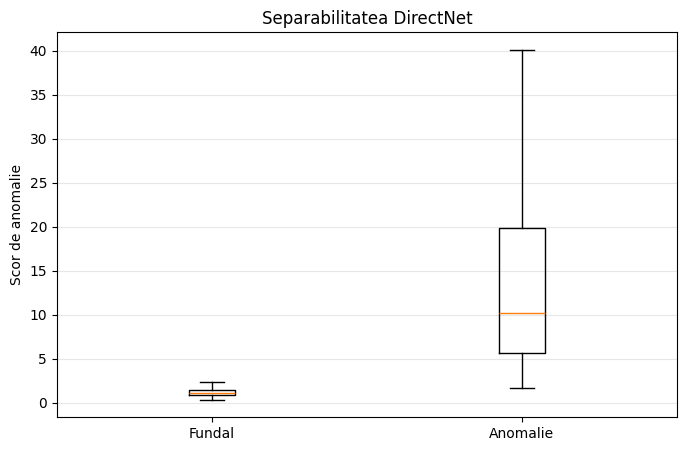

Mediană fundal: 1.031829595565796
Mediană anomalie: 10.198312759399414


In [ ]:
background_scores = scores[y_true == 0]
anomaly_scores = scores[y_true == 1]

plt.figure(figsize=(8, 5))
plt.boxplot([background_scores, anomaly_scores], labels=["Fundal", "Anomalie"], showfliers=False)
plt.ylabel("Scor de anomalie")
plt.title("Separabilitatea DirectNet")
plt.grid(axis="y", alpha=0.3)
plt.show()

print("Mediană fundal:", float(np.median(background_scores)))
print("Mediană anomalie:", float(np.median(anomaly_scores)))

## 15. Salvarea modelului și a rezultatelor

In [ ]:
MODEL_PATH = DATA_DIR / f"directnet_pavia_wout{WOUT}_win{WIN}.pt"
RESULTS_PATH = DATA_DIR / f"directnet_pavia_wout{WOUT}_win{WIN}_results.npz"

torch.save({
    "model_state_dict": model.state_dict(),
    "bands": B,
    "wout": WOUT,
    "win": WIN,
    "best_val_loss": best_val,
    "history": history,
}, MODEL_PATH)

np.savez_compressed(
    RESULTS_PATH,
    gt=gt_binary,
    pca_rgb=pca_rgb,
    directnet_map=directnet_map,
    auc_directnet=np.array([auc_directnet], dtype=np.float32),
    auc_grx=np.array([auc_grx], dtype=np.float32),
    threshold=np.array([threshold], dtype=np.float32),
    tp=np.array([tp]), tn=np.array([tn]), fp=np.array([fp]), fn=np.array([fn]),
    precision=np.array([precision]), recall=np.array([recall]), f1=np.array([f1]),
    training_time=np.array([training_time]), inference_time=np.array([inference_time]),
)

print("Model:", MODEL_PATH)
print("Rezultate:", RESULTS_PATH)

Model: /content/directnet_data/directnet_pavia_wout19_win3.pt
Rezultate: /content/directnet_data/directnet_pavia_wout19_win3_results.npz


# Ce trebuie notat după rulare

- AUC GRX:
- AUC DirectNet:
- Diferență AUC:
- Număr epoci:
- Timp de antrenare:
- Timp de inferență:
- Precision:
- Recall:
- F1:
- FP:
- FN:

Următorul pas va fi studiul hiperparametrilor:

- `Win ∈ {1, 3, 5, 7, 9}`;
- `Wout ∈ {15, 19, 23}`;
- grafice AUC versus hiperparametri;
- selectarea și explicarea unor cazuri concrete FP/FN.